# Tunable compliance — emergent grasps

## In-hand manipulation

The hand closes to a PC1 grasp and two asymmetric stiffness configurations are applied:
**Stiff Thumb** (Side B = thumb+index+middle at $K_\mathrm{high}$, Side A = pinky+ring at $K_\mathrm{low}$) and **Soft Thumb** (sides swapped).
The spring length is the task-spring elongation $\|\Delta p\|$ from the PC1 reference fingertip position.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
from pathlib import Path

sys.path.insert(0, os.path.join('../../'))
from plot_config import draw_radar

FINGERTIPS   = ['thumb', 'index', 'middle', 'ring', 'pinky']
PHASES       = ['asym_a', 'asym_b']
PHASE_LABELS = {'asym_a': 'Stiff Thumb', 'asym_b': 'Soft Thumb'}
PHASE_COLORS = {'asym_a': '#E69F00', 'asym_b': '#D55E00'}

SIDE_A = ['pinky', 'ring']             # K_low in Stiff Thumb, K_high in Soft Thumb
SIDE_B = ['thumb', 'index', 'middle']  # K_high in Stiff Thumb, K_low in Soft Thumb

OUTPUT_INHAND = os.path.join('outputs', 'inhand_manipulation')
os.makedirs(OUTPUT_INHAND, exist_ok=True)


def load_inhand():
    path = Path(OUTPUT_INHAND) / 'inhand_run.csv'
    return pd.read_csv(path) if path.exists() else None


df = load_inhand()
if df is None:
    print('No data — run inhand_manipulation.py first.')
else:
    print(df['phase'].value_counts().to_dict())

{'uniform': 96, 'asym_b': 94, 'asym_a': 92}


### Spring length per finger

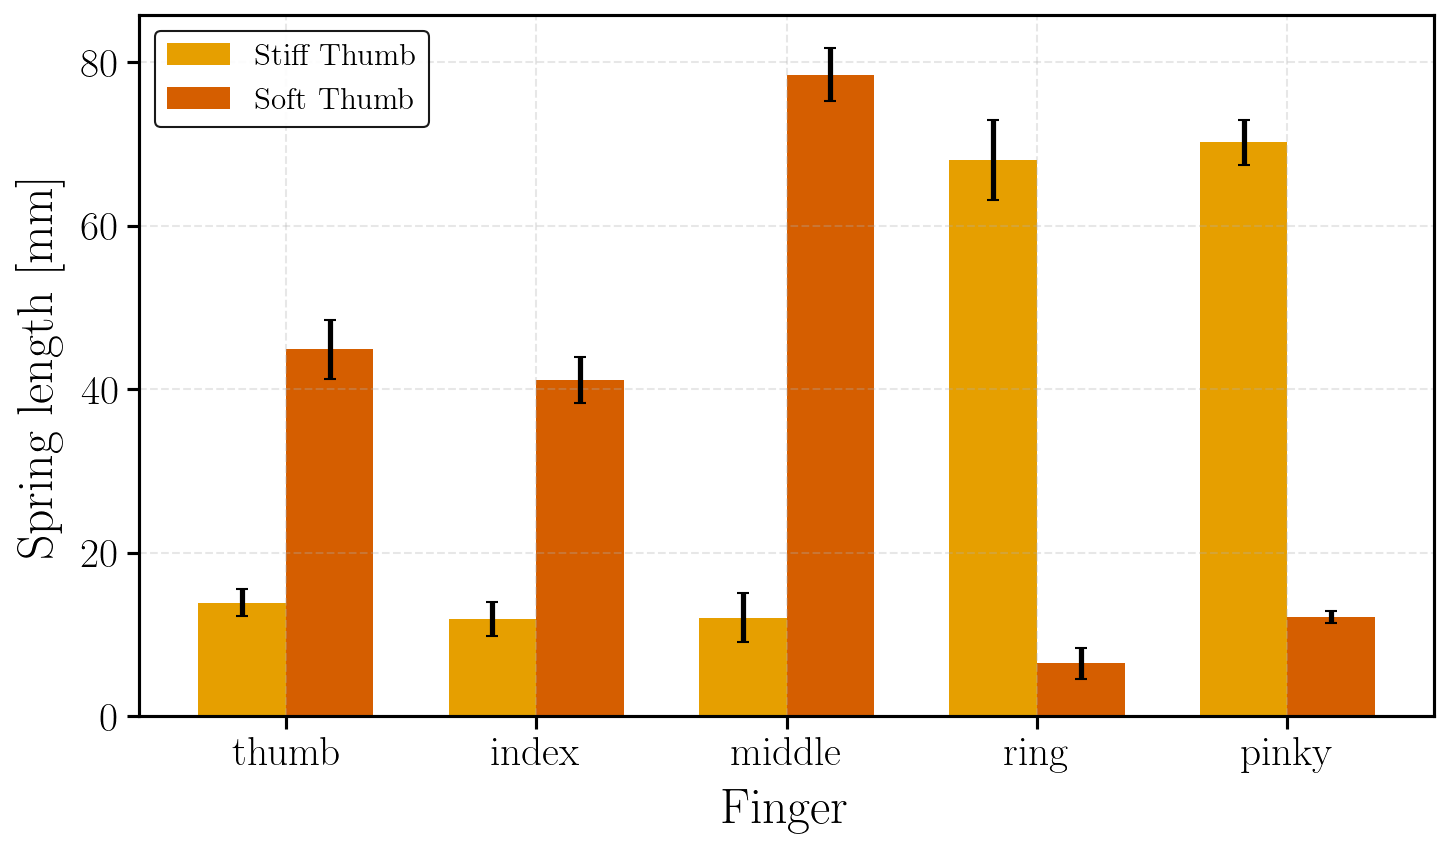

In [26]:
fig, ax = plt.subplots()
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, phase in enumerate(PHASES):
    means, stds = [], []
    for f in FINGERTIPS:
        if df is not None:
            rows = df[df['phase'] == phase]
            mag  = np.sqrt(rows[f'disp_{f}_x_m']**2 +
                           rows[f'disp_{f}_y_m']**2 +
                           rows[f'disp_{f}_z_m']**2) * 1e3
            means.append(float(mag.mean()))
            stds.append(float(mag.std()))
        else:
            means.append(0.0); stds.append(0.0)
    ax.bar(x + i * width, means, width, yerr=stds, capsize=3,
           label=PHASE_LABELS[phase], color=PHASE_COLORS[phase])

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel('Spring length [mm]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_INHAND, 'inhand_spring_length.pdf'), bbox_inches='tight')
plt.show()

Finger spring lengths (mm):


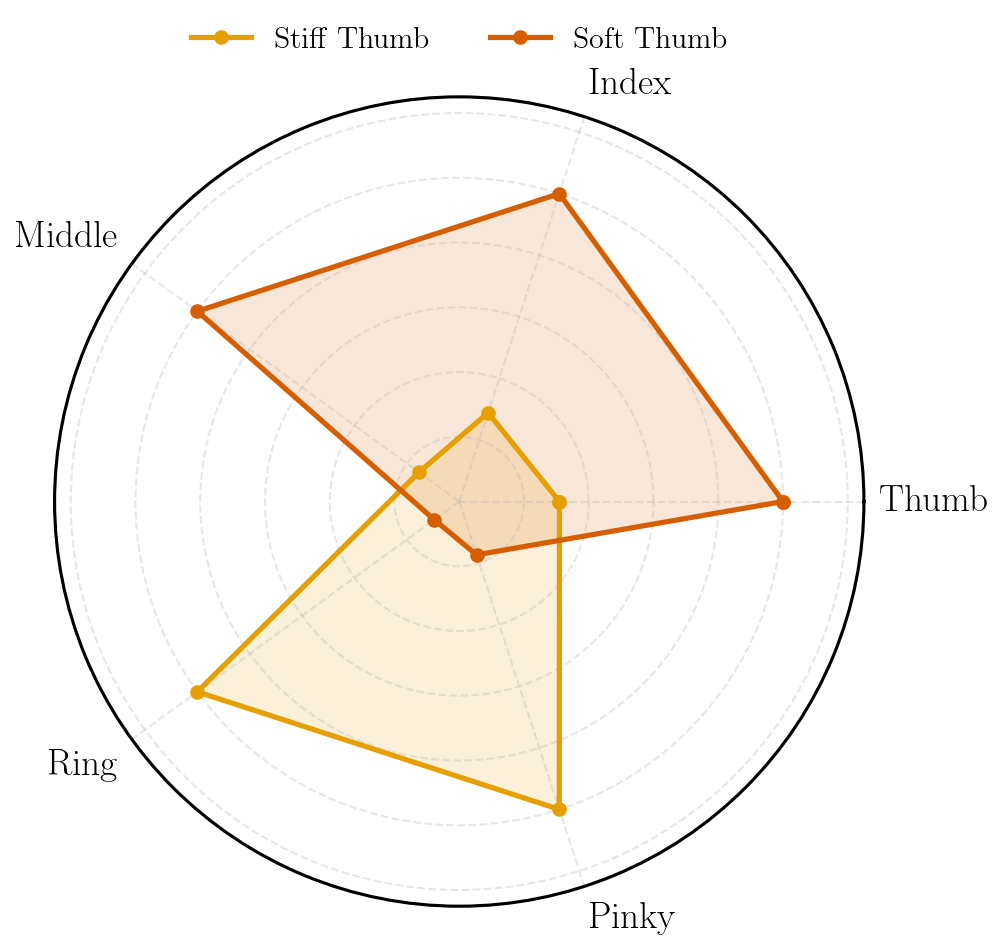

(<Figure size 1050x1050 with 1 Axes>, <PolarAxes: >)

In [27]:
traces = []
for phase in PHASES:
    means = []
    for f in FINGERTIPS:
        if df is not None:
            rows = df[df['phase'] == phase]
            mag  = np.sqrt(rows[f'disp_{f}_x_m']**2 +
                           rows[f'disp_{f}_y_m']**2 +
                           rows[f'disp_{f}_z_m']**2) * 1e3
            means.append(float(mag.mean()))
        else:
            means.append(0.0)
    traces.append({'label': PHASE_LABELS[phase], 'values': means, 'color': PHASE_COLORS[phase]})

print("Finger spring lengths (mm):")
draw_radar(
    [f.capitalize() for f in FINGERTIPS],
    traces,
    os.path.join(OUTPUT_INHAND, 'radar_spring_length.pdf'),
)

### Contact force magnitude per finger

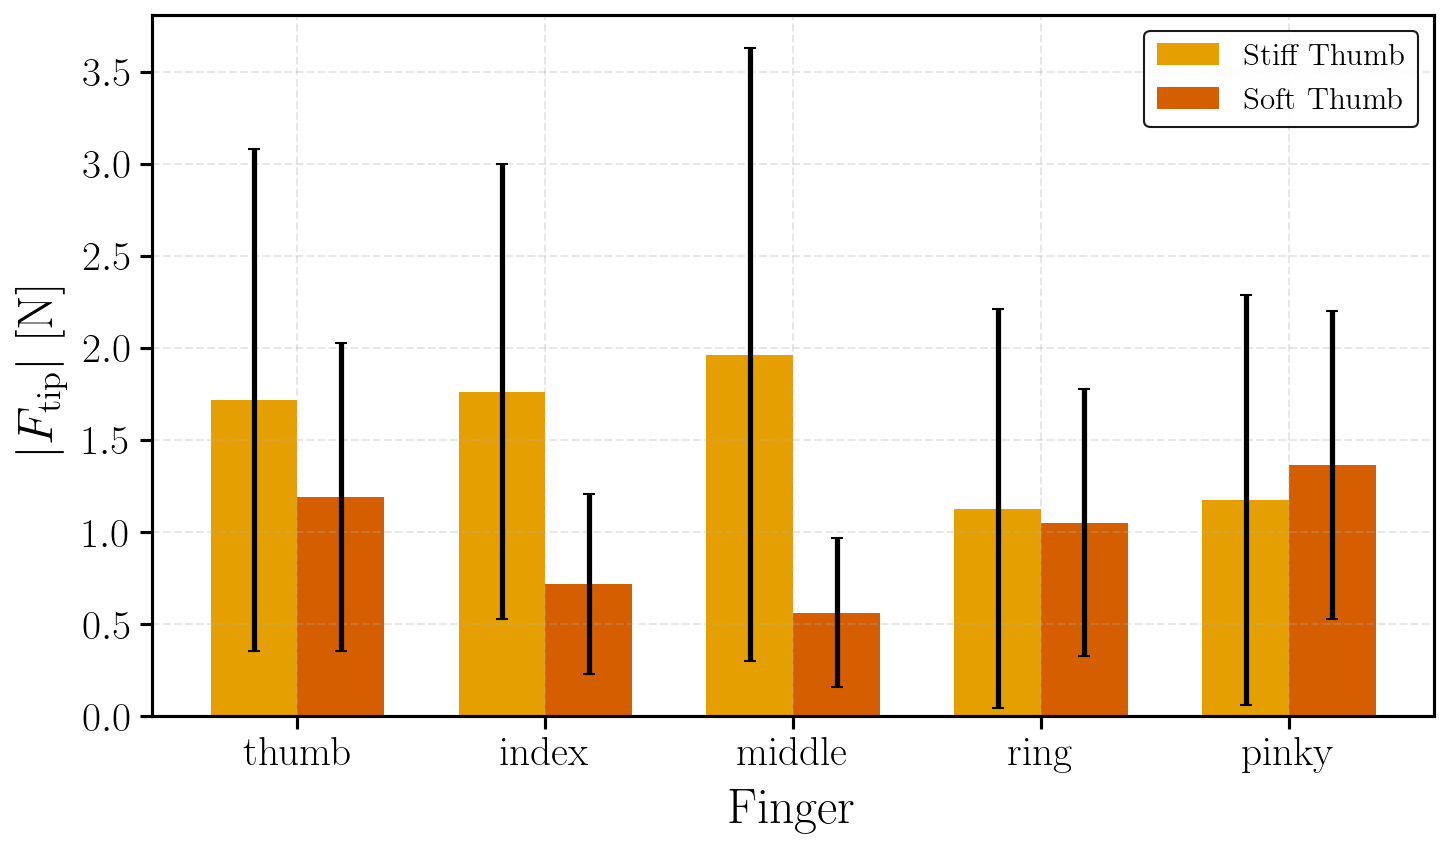

In [28]:
fig, ax = plt.subplots()
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, phase in enumerate(PHASES):
    means, stds = [], []
    for f in FINGERTIPS:
        col = f'force_1st_{f}_mag_N'
        if df is not None and col in df.columns:
            rows = df[df['phase'] == phase]
            means.append(float(rows[col].mean()))
            stds.append(float(rows[col].std()))
        else:
            means.append(0.0); stds.append(0.0)
    ax.bar(x + i * width, means, width, yerr=stds, capsize=3,
           label=PHASE_LABELS[phase], color=PHASE_COLORS[phase])

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel(r'$|F_{\mathrm{tip}}|$ [N]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_INHAND, 'inhand_force.pdf'), bbox_inches='tight')
plt.show()

Finger contact forces (N):


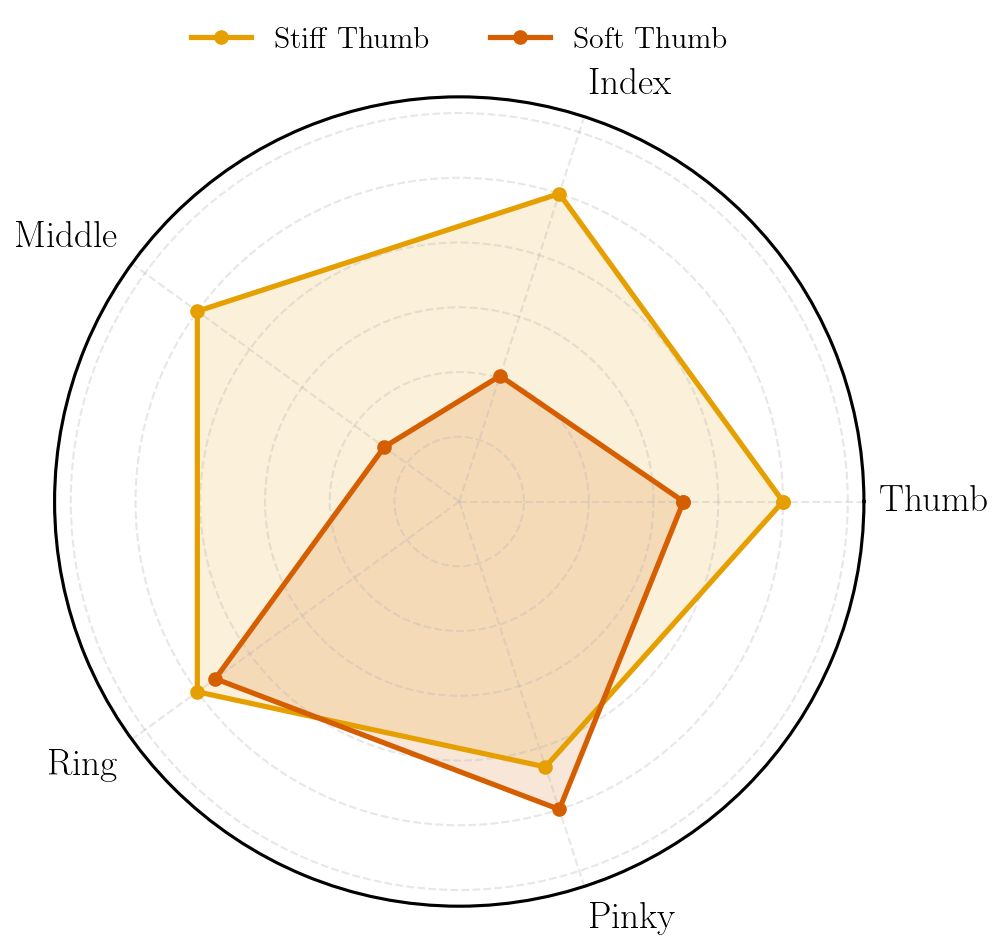

(<Figure size 1050x1050 with 1 Axes>, <PolarAxes: >)

In [29]:
traces = []
for phase in PHASES:
    means = []
    for f in FINGERTIPS:
        col = f'force_1st_{f}_mag_N'
        if df is not None and col in df.columns:
            rows = df[df['phase'] == phase]
            means.append(float(rows[col].mean()))
        else:
            means.append(0.0)
    traces.append({'label': PHASE_LABELS[phase], 'values': means, 'color': PHASE_COLORS[phase]})

print("Finger contact forces (N):")
draw_radar(
    [f.capitalize() for f in FINGERTIPS],
    traces,
    os.path.join(OUTPUT_INHAND, 'radar_force.pdf'),
)

### Final hand pose per phase

The motor configuration $q$ at the end of **Stiff Thumb** and **Soft Thumb** rendered with `ModelIDHand.hand_viz`.

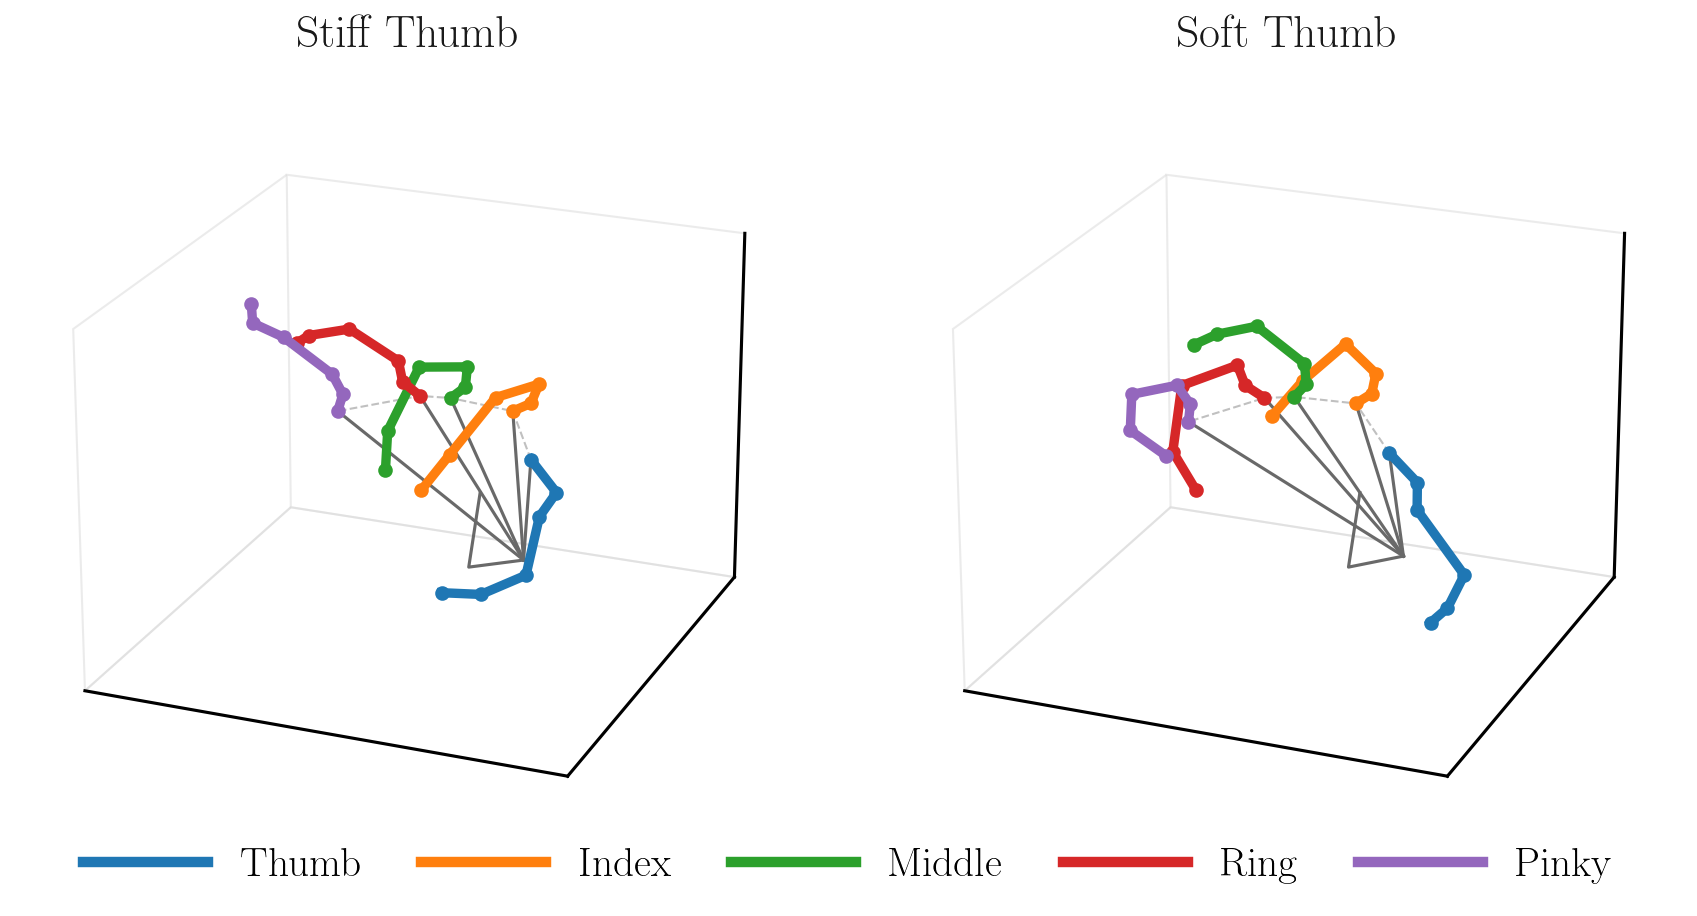

In [30]:
from ModelIDHand.hand_viz import plot_hand, _COL

_FIN_ALL = ['thumb', 'index', 'middle', 'ring', 'pinky']
_STYLE   = dict(linestyle='-', linewidth=4.5, marker='o', markersize=6.0)
_ELEV, _AZIM = 22, 112

INHAND_SNAP_PHASES = ['asym_a', 'asym_b']
INHAND_TITLES  = {'asym_a':  'Stiff Thumb',
                  'asym_b':  'Soft Thumb'}

_Q_COLS = [f'q_motor_{i}_rad' for i in range(15)]


def _polish_ax(ax, title):
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel(''); ax.set_ylabel(''); ax.set_zlabel('')
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False
        pane.set_edgecolor('#d8d8d8')
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis._axinfo['grid']['color']     = (0.88, 0.88, 0.88, 0.6)
        axis._axinfo['grid']['linewidth'] = 0.4
    ax.view_init(elev=_ELEV, azim=_AZIM)
    ax.set_title(title, fontsize=plt.rcParams['axes.titlesize'],
                 fontweight='semibold', pad=14, color='#1a1a1a')


def _sync_axes(axes):
    lims = np.array([[a.get_xlim3d(), a.get_ylim3d(), a.get_zlim3d()] for a in axes])
    xl = [lims[:, 0, 0].min(), lims[:, 0, 1].max()]
    yl = [lims[:, 1, 0].min(), lims[:, 1, 1].max()]
    zl = [lims[:, 2, 0].min(), lims[:, 2, 1].max()]
    span = max(xl[1] - xl[0], yl[1] - yl[0], zl[1] - zl[0])
    cx, cy, cz = 0.5 * sum(xl), 0.5 * sum(yl), 0.5 * sum(zl)
    for a in axes:
        a.set_xlim3d(cx - span / 2, cx + span / 2)
        a.set_ylim3d(cy - span / 2, cy + span / 2)
        a.set_zlim3d(cz - span / 2, cz + span / 2)


_LEG = [plt.Line2D([0], [0], color=_COL[n], lw=5.0, ls='-', label=n.capitalize())
        for n in _FIN_ALL]

if df is not None:
    fig = plt.figure(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    axes = []
    for i, phase in enumerate(INHAND_SNAP_PHASES):
        rows = df[df['phase'] == phase]
        if rows.empty:
            continue
        q = rows[_Q_COLS].iloc[-1].to_numpy(dtype=np.float64)
        ax = fig.add_subplot(1, 2, i + 1, projection='3d')
        plot_hand(q, ax=ax, style=_STYLE)
        leg = ax.get_legend()
        if leg: leg.remove()
        _polish_ax(ax, INHAND_TITLES[phase])
        axes.append(ax)
    _sync_axes(axes)
    fig.legend(handles=_LEG, loc='lower center', ncol=5,
               fontsize=plt.rcParams['legend.fontsize'], frameon=False,
               bbox_to_anchor=(0.5, -0.02), handlelength=3.0, columnspacing=1.4)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_INHAND, 'inhand_hand_pose.pdf'),
                bbox_inches='tight', dpi=300)
    plt.show()

## Dynamic grasping

The UR5 slides the hand along +X. The hand closes to PC1 at a fixed distance under three stiffness schedules:
**Soft** ($K_\mathrm{soft}$ throughout), **Stiff** ($K_\mathrm{stiff}$ throughout),
**Adaptive** ($K_\mathrm{soft}$ at close, then ramps to $K_\mathrm{stiff}$).

In [31]:
OUTPUT_GRASP = os.path.join('outputs', 'dynamic_grasp')
os.makedirs(OUTPUT_GRASP, exist_ok=True)

CONDITIONS    = ['soft', 'stiff', 'adaptive']
COND_LABELS   = {'soft': 'Soft', 'stiff': 'Stiff', 'adaptive': 'Adaptive'}
COND_COLORS   = {'soft': '#56B4E9', 'stiff': '#D55E00', 'adaptive': '#009E73'}


def load_dynamic(condition):
    path = Path(OUTPUT_GRASP) / f'dynamic_grasp_{condition}.csv'
    return pd.read_csv(path) if path.exists() else None


# Steady-state window: last 20 % of the post-close samples.
def _steady(df_dg):
    closed = df_dg[df_dg['phase'] != 'open']
    return closed.tail(max(1, len(closed) // 5)) if not closed.empty else closed


dfs_dg = {c: load_dynamic(c) for c in CONDITIONS}
print({c: (len(d) if d is not None else 0) for c, d in dfs_dg.items()})

{'soft': 503, 'stiff': 504, 'adaptive': 505}


### Spring length per finger

Task-spring elongation $\|\Delta p\|$ averaged over the last 20 % of the post-close samples (steady-state).

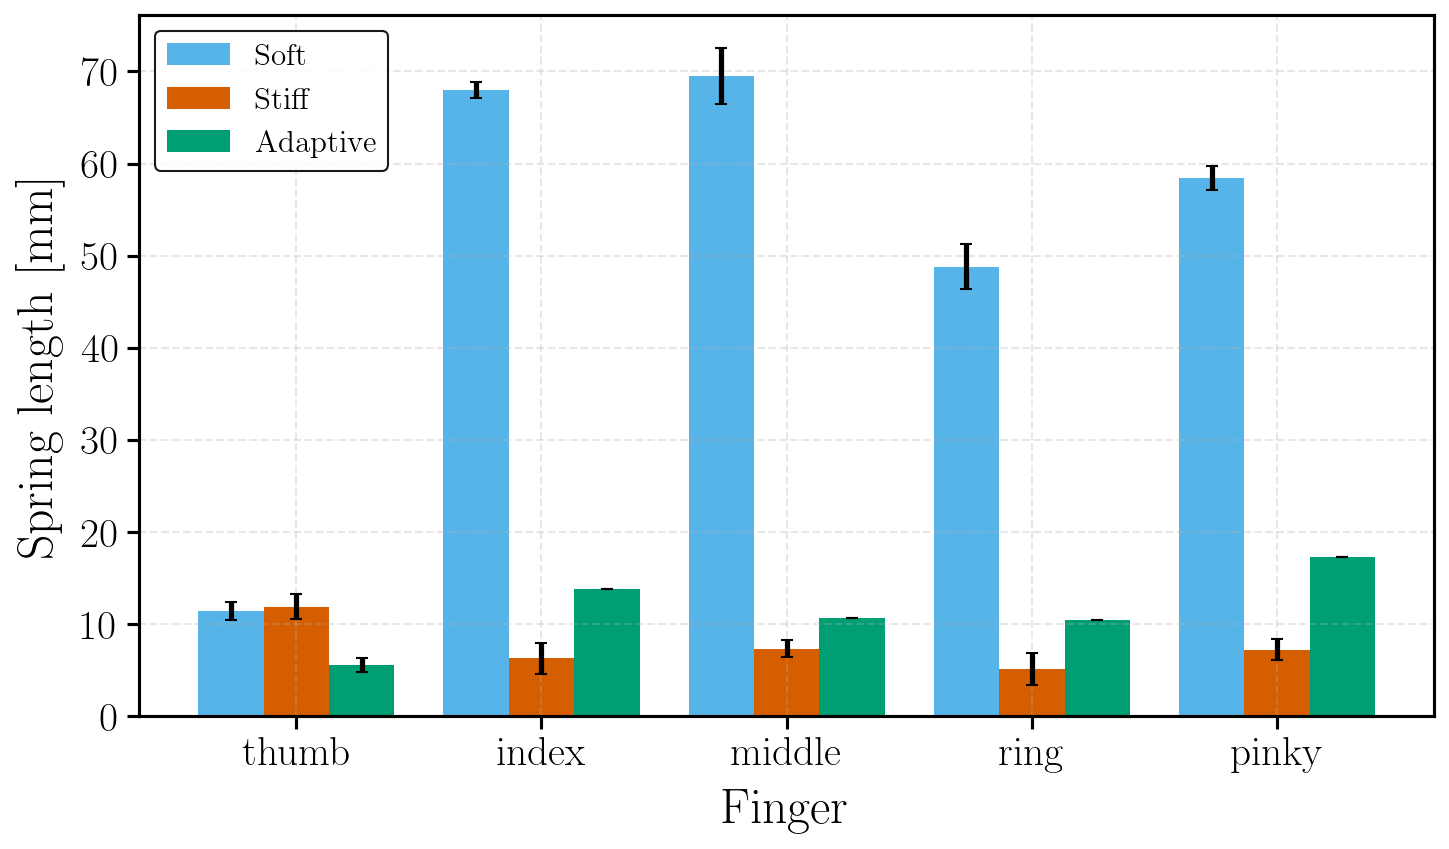

In [32]:
fig, ax = plt.subplots()
x = np.arange(len(FINGERTIPS))
width = 0.8 / len(CONDITIONS)

for i, cond in enumerate(CONDITIONS):
    df_dg = dfs_dg.get(cond)
    means, stds = [], []
    for f in FINGERTIPS:
        if df_dg is None or df_dg.empty:
            means.append(0.0); stds.append(0.0); continue
        rows = _steady(df_dg)
        mag  = np.sqrt(rows[f'disp_{f}_x_m']**2 +
                       rows[f'disp_{f}_y_m']**2 +
                       rows[f'disp_{f}_z_m']**2) * 1e3
        means.append(float(mag.mean()))
        stds.append(float(mag.std()))
    ax.bar(x + i * width, means, width, yerr=stds, capsize=3,
           label=COND_LABELS[cond], color=COND_COLORS[cond])

ax.set_xticks(x + width * (len(CONDITIONS) - 1) / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel('Spring length [mm]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_spring_length.pdf'),
            bbox_inches='tight')
plt.show()

Finger spring lengths (mm):


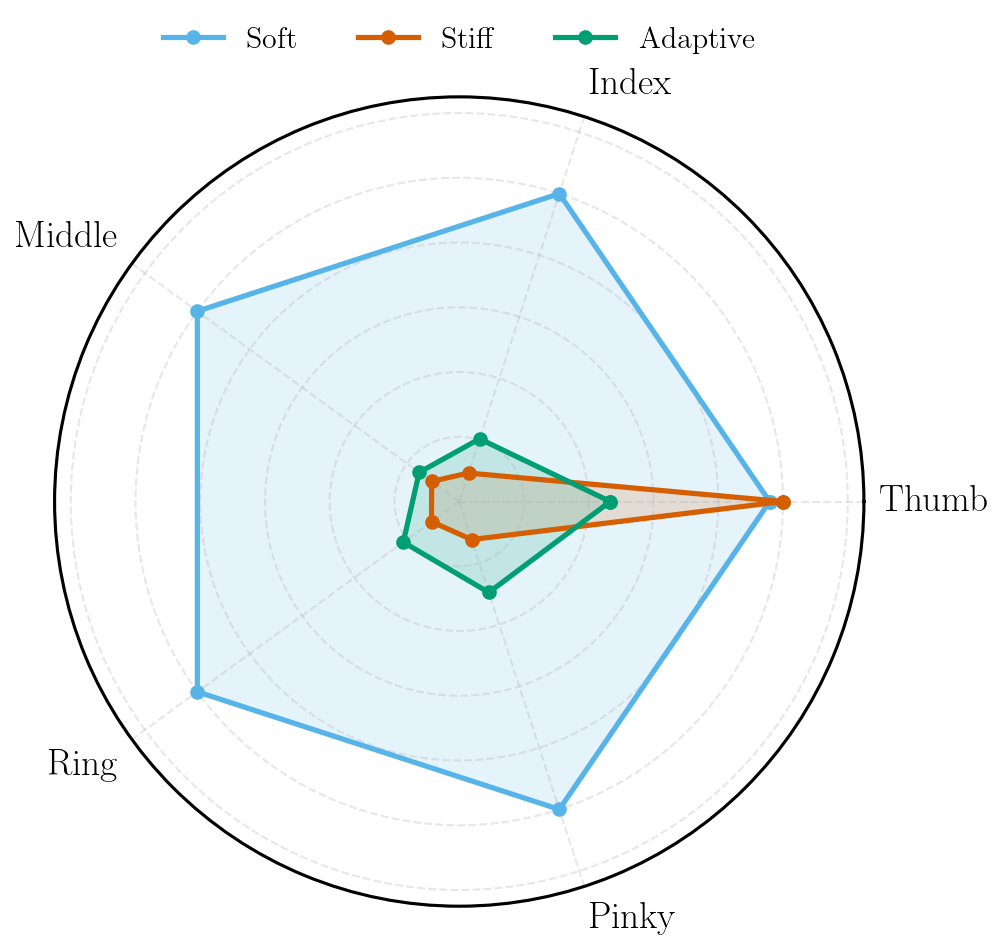

(<Figure size 1050x1050 with 1 Axes>, <PolarAxes: >)

In [33]:
traces = []
for cond in CONDITIONS:
    df_dg = dfs_dg.get(cond)
    means = []
    for f in FINGERTIPS:
        if df_dg is None or df_dg.empty:
            means.append(0.0); continue
        rows = _steady(df_dg)
        mag  = np.sqrt(rows[f'disp_{f}_x_m']**2 +
                       rows[f'disp_{f}_y_m']**2 +
                       rows[f'disp_{f}_z_m']**2) * 1e3
        means.append(float(mag.mean()))
    traces.append({'label': COND_LABELS[cond], 'values': means, 'color': COND_COLORS[cond]})

print("Finger spring lengths (mm):")
draw_radar(
    [f.capitalize() for f in FINGERTIPS],
    traces,
    os.path.join(OUTPUT_GRASP, 'dynamic_grasp_spring_length_radar.pdf'),
)

### Contact force magnitude per finger

Tip-force magnitude $|F_\mathrm{tip}|$ averaged over the steady-state window.

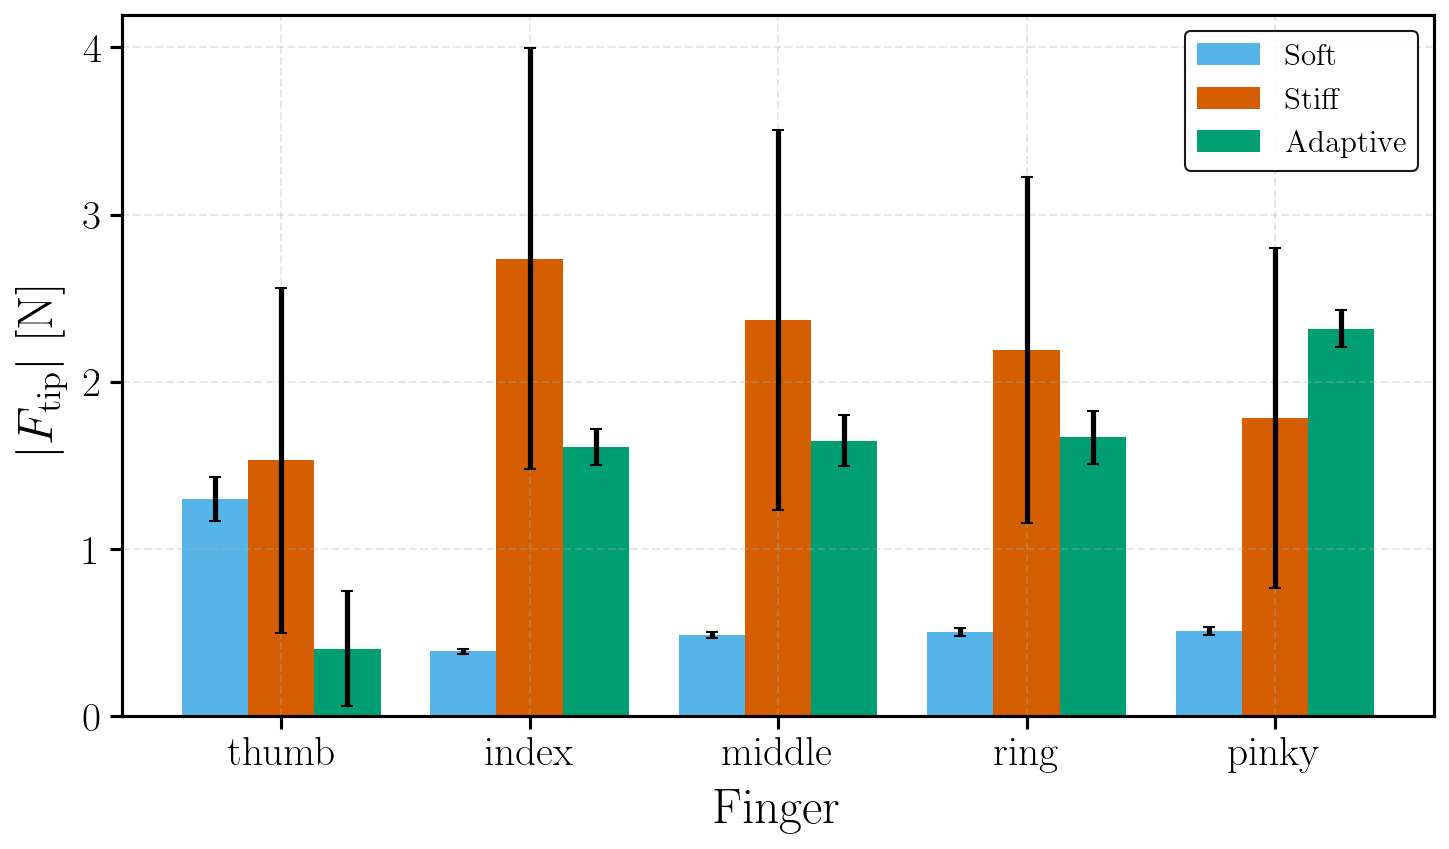

In [34]:
fig, ax = plt.subplots()
x = np.arange(len(FINGERTIPS))
width = 0.8 / len(CONDITIONS)

for i, cond in enumerate(CONDITIONS):
    df_dg = dfs_dg.get(cond)
    means, stds = [], []
    for f in FINGERTIPS:
        col = f'force_{f}_mag_N'
        if df_dg is None or df_dg.empty or col not in df_dg.columns:
            means.append(0.0); stds.append(0.0); continue
        rows = _steady(df_dg)
        means.append(float(rows[col].mean()))
        stds.append(float(rows[col].std()))
    ax.bar(x + i * width, means, width, yerr=stds, capsize=3,
           label=COND_LABELS[cond], color=COND_COLORS[cond])

ax.set_xticks(x + width * (len(CONDITIONS) - 1) / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel(r'$|F_{\mathrm{tip}}|$ [N]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_force_bar.pdf'),
            bbox_inches='tight')
plt.show()

Finger contact forces (N):


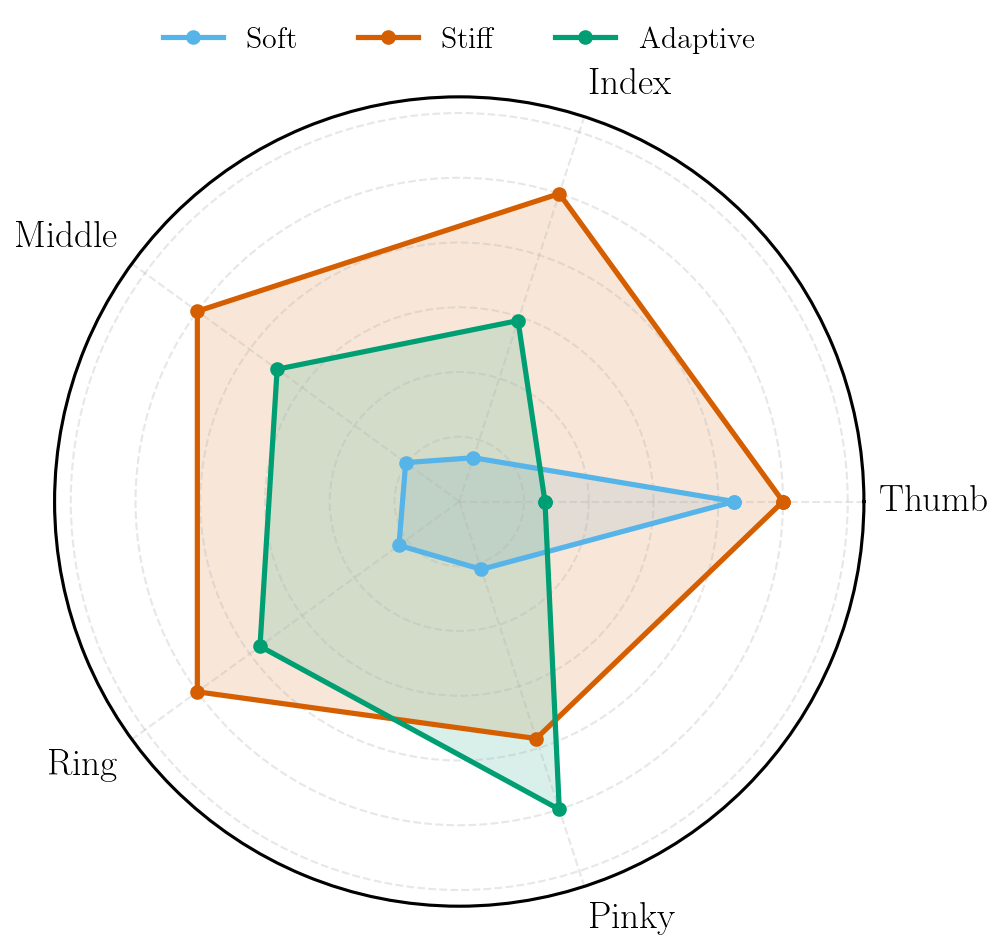

(<Figure size 1050x1050 with 1 Axes>, <PolarAxes: >)

In [35]:
traces = []
for cond in CONDITIONS:
    df_dg = dfs_dg.get(cond)
    means = []
    for f in FINGERTIPS:
        col = f'force_{f}_mag_N'
        if df_dg is None or df_dg.empty or col not in df_dg.columns:
            means.append(0.0); continue
        rows = _steady(df_dg)
        means.append(float(rows[col].mean()))
    traces.append({'label': COND_LABELS[cond], 'values': means, 'color': COND_COLORS[cond]})

print("Finger contact forces (N):")
draw_radar(
    [f.capitalize() for f in FINGERTIPS],
    traces,
    os.path.join(OUTPUT_GRASP, 'dynamic_grasp_force_radar.pdf'),
)

### Final hand pose per condition

The motor configuration $q$ at the end of the **Soft**, **Stiff**, and **Adaptive** grasps.

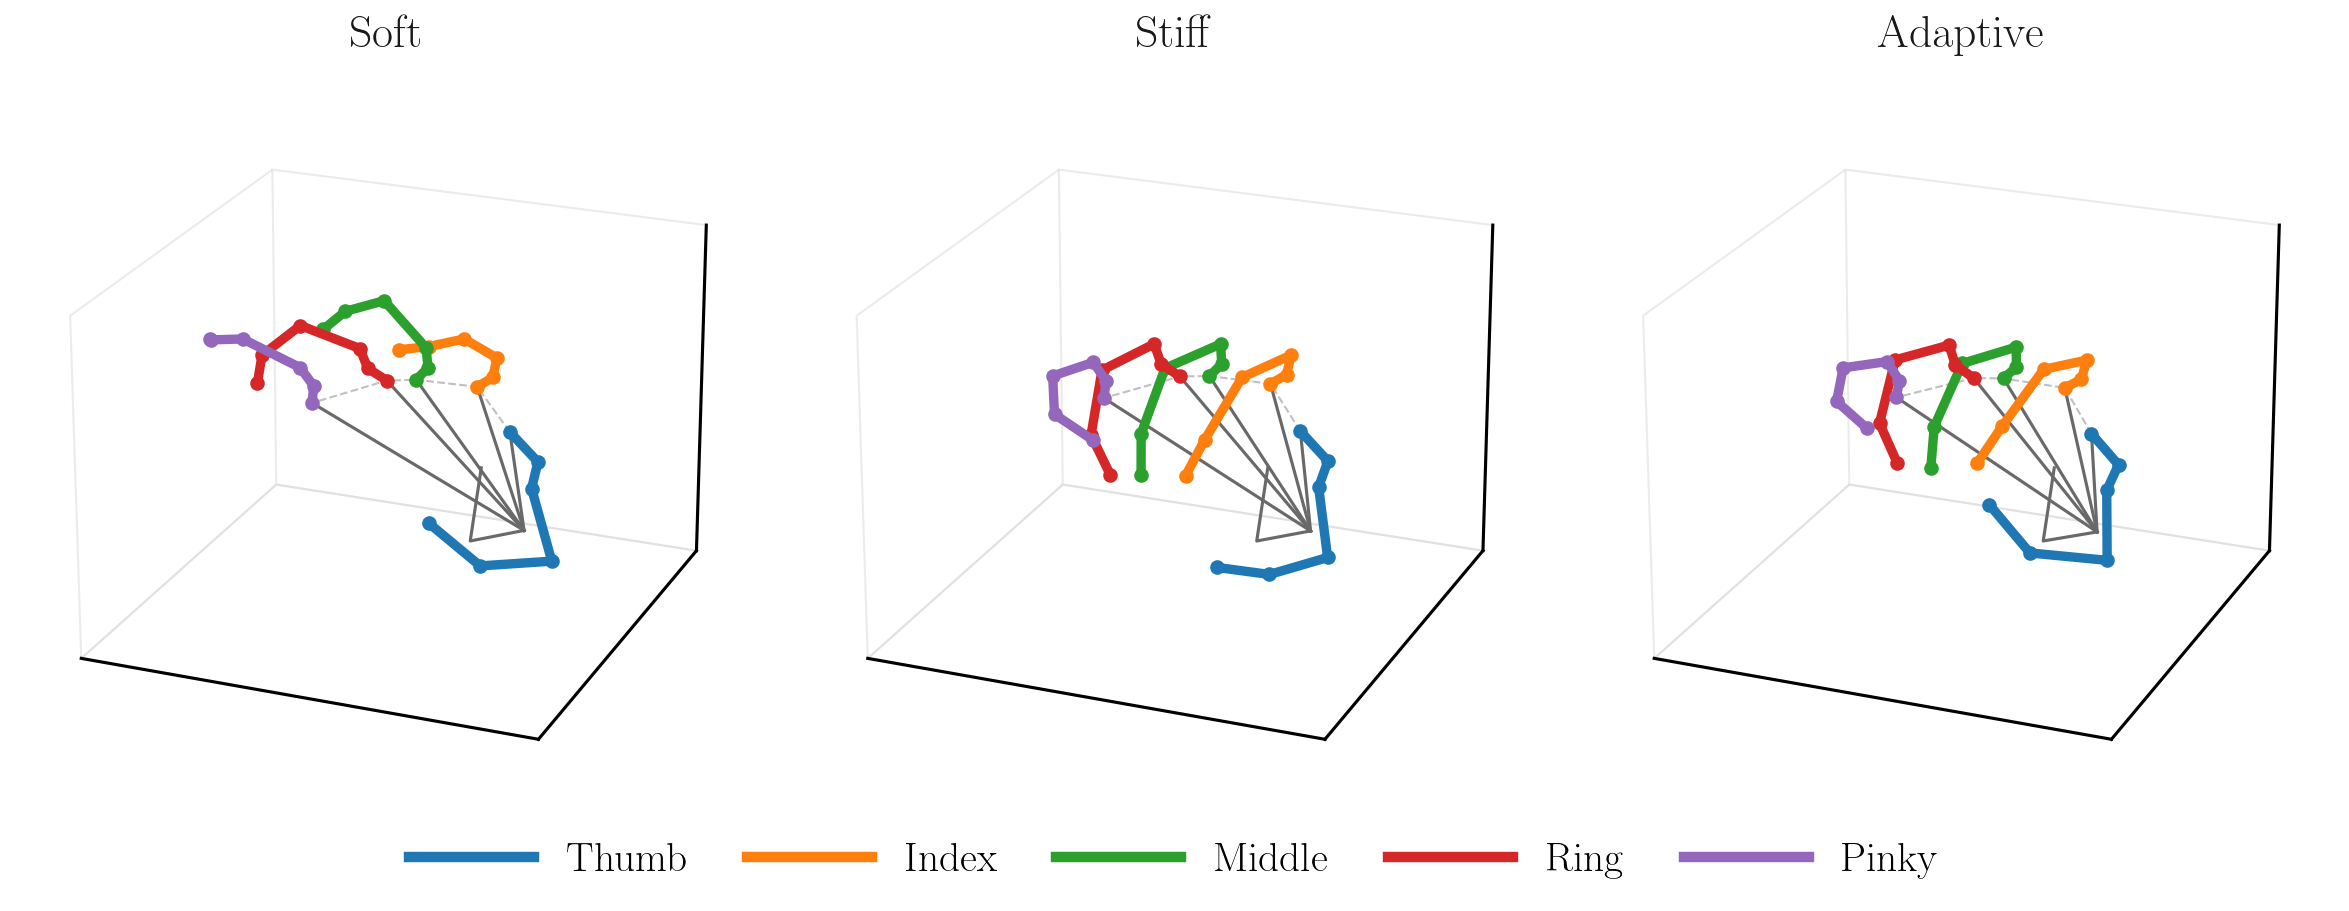

In [36]:
DG_SNAP_CONDS = ['soft', 'stiff', 'adaptive']
_Q_COLS_DG = [f'q_{i}' for i in range(15)]

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor('white')
axes = []
for i, cond in enumerate(DG_SNAP_CONDS):
    df_dg = dfs_dg.get(cond)
    if df_dg is None or df_dg.empty:
        continue
    closed = df_dg[df_dg['phase'] != 'open']
    rows   = closed if not closed.empty else df_dg
    q = rows[_Q_COLS_DG].iloc[-1].to_numpy(dtype=np.float64)
    ax = fig.add_subplot(1, len(DG_SNAP_CONDS), i + 1, projection='3d')
    plot_hand(q, ax=ax, style=_STYLE)
    leg = ax.get_legend()
    if leg: leg.remove()
    _polish_ax(ax, COND_LABELS[cond])
    axes.append(ax)
_sync_axes(axes)
fig.legend(handles=_LEG, loc='lower center', ncol=5,
           fontsize=plt.rcParams['legend.fontsize'], frameon=False,
           bbox_to_anchor=(0.5, -0.02), handlelength=3.0, columnspacing=1.4)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_hand_pose.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()